In [1]:
import os 
from pathlib import Path
import numpy as np
import glob
import xarray as xr
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
os.chdir(Path('/home/globc/garcia/'))

from scenarIA.src.utils.plotutils import plot_mean_std_simulations
from scenarIA.src.utils.settings import DATASET_DIR, GRAPHS_DIR
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean


/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [4]:
colors_dict = {'historical':'k',
              'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
labels = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
vmin = {'tas': 285 - 273.15, 'pr': 2.75}
vmax = {'tas': 293 - 273.15, 'pr': 3.25}
#vmin = {'tas': -1, 'pr': -0.05} #changes
#vmax = {'tas': 5, 'pr': 0.15}

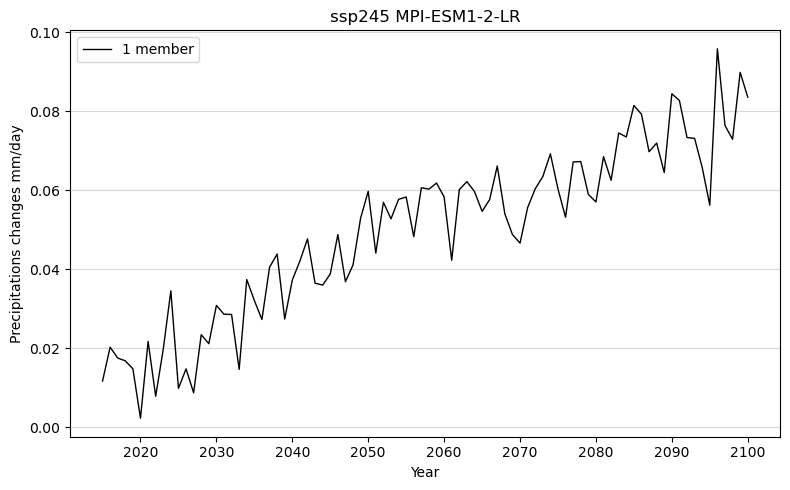

In [26]:
var_name = 'pr'
simu = 'ssp245'
unit = 'mm/day'
color = 'k'

# clim
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_piControl.nc')[[var_name]].mean('member')
clim = clim.mean('time')
climatology = clim.to_array().transpose('lat', 'lon', 'variable').to_numpy()

file = DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}.nc'
ds = xr.open_dataset(file)
ds = dataset_xr_formatting(ds, original_time_format = "%Y")
ds = ds[var_name]
time = ds.time.values
ds.values = ds.values - climatology

custom_lines = [Line2D([0], [0], color='k', lw=1)]


plt.figure(figsize=(8, 5)) 
mem_list = []
for member in range(1):
    dsi = ds.isel(member=member)
    dsi = weighted_global_mean(dsi)
    data = dsi.values
    mem_list.append(data)
    plt.plot(time, data, label=simu, color=color, linewidth=1, alpha=1)
#plt.plot(time, np.stack(mem_list, axis=0).mean(axis=0), color = 'red', linewidth=3)
plt.grid(axis='y', alpha = 0.5)
plt.ylabel(f'Precipitations changes {unit}')
plt.xlabel('Year')
#plt.ylim(14, 17)
plt.legend(custom_lines, ['1 member'], loc ='upper left')
plt.title('ssp245 MPI-ESM1-2-LR')
plt.tight_layout()

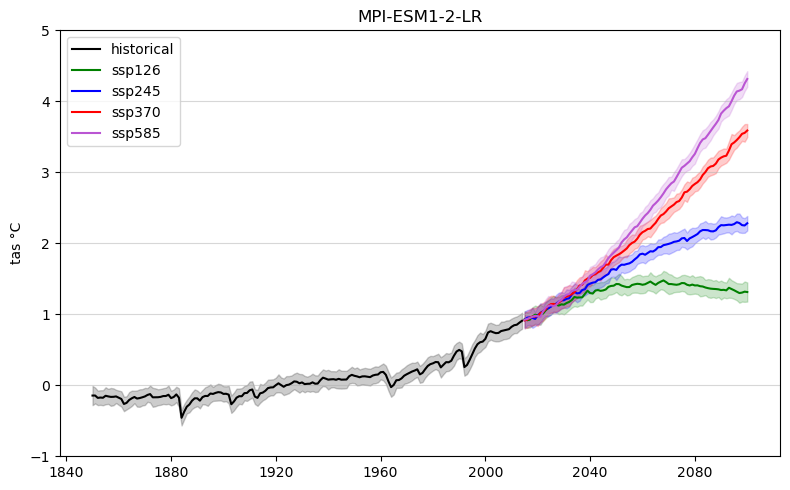

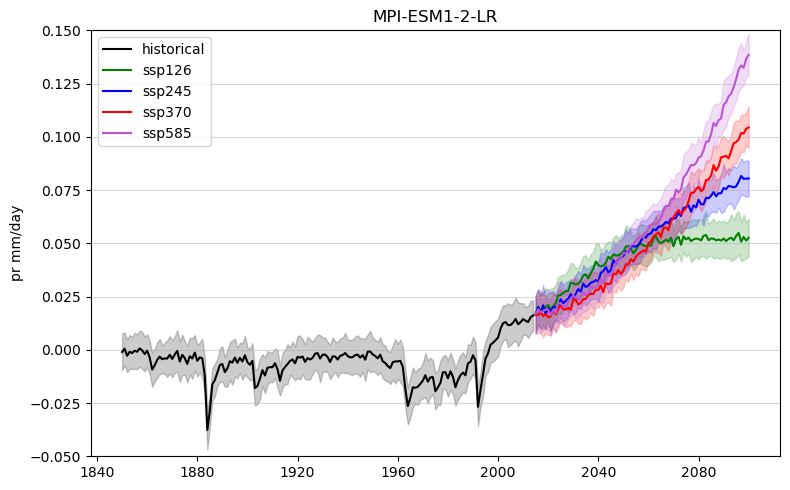

In [5]:

root_dir = DATASET_DIR / 'MPI-ESM1-2-LR/annual/'
files_dict = {}
for simu in labels:
    files_dict[simu] = root_dir / f'outputs_{simu}.nc'

for var in ['tas', 'pr']:
    plot_mean_std_simulations(files_dict,
                              var_name=var,
                              colors_dict = colors_dict,
                              title='MPI-ESM1-2-LR',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=root_dir / f'MPI-ESM1-2-LR_{var}_temporal_evolution.png'
                              )

In [ ]:
labels = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
colors_dict = {'historical':'k',
              'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
root_dir = Path('/scratch/globc/garcia/common_data/CNRM-CM6-1/')


In [9]:
files_dict = {}

for var in ['tas', 'pr']:

    for exp in labels:
        if exp.startswith('ssp'):
            exp_paths = np.sort(glob.glob(str(f'/scratch/globc/garcia/common_data/CNRM-CM6-1/{exp}/{var}*reformat*.nc')))
        else:   
            exp_paths = glob.glob(str(f'/scratch/globc/garcia/common_data/CNRM-CM6-1/{exp}/{var}*185001-201412.nc'))
        files_dict[exp] = exp_paths

    plot_mean_std_simulations(files_dict,
                              var_name = var,
                              colors_dict = colors_dict,
                              time_res = 'm',
                              title='CNRM-CM6-1',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=GRAPHS_DIR / f'tests/CNRM-CM6-1_Amon_{var}_temporal_evolution.png'
                              )

KeyboardInterrupt: 

<Figure size 600x400 with 0 Axes>

In [ ]:
root_path = '/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/MPI-ESM1-2-LR/mon/'
files_dict = {}

for var in ['tas', 'pr']:

    for exp in labels:
        exp_paths = glob.glob(root_path + f'{exp}/{var}_Amon_MPI-ESM1-2-LR_{exp}_r1i1p1f1_gn_*.nc')
        files_dict[exp] = exp_paths
    print(files_dict)

    plot_mean_std_simulations(files_dict,
                              var_name = var,
                              colors_dict = colors_dict,
                              time_res = 'm',
                              title='MPI-ESM1-2-LR (Amon)',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=GRAPHS_DIR / f'tests/MPI-ESM1-2-LR_Amon_{var}_temporal_evolution.png'
                              )